In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("..")
from skrmt.denoise.mp_pca import MarchenkoPasturPCADenoiser

In [3]:
def plot_slices(slices, titles=None, cmap="gray", origin="lower"):
    """Function to display a row of image slices."""
    n_slices = len(slices)
    fig, axes = plt.subplots(1, n_slices, figsize=(3.5 * n_slices, 3.8))

    if len(slices) > 1:
        for i, slice_array in enumerate(slices):
            axes[i].imshow(slice_array, cmap=cmap, origin=origin, aspect="auto")
            if titles is not None:
                axes[i].set_title(titles[i])
            axes[i].grid(False)
    else:
        axes.imshow(slices[0], cmap=cmap, origin=origin)
        if titles is not None:
            axes.set_title(titles[0])
        axes.grid(False)

In [4]:
tumor_slice = np.load("sim_data/sample_tumor_img.npy")
tumor_slice.shape

(184, 132)

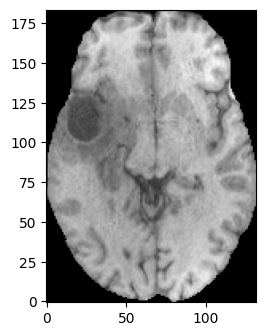

In [5]:
plot_slices([tumor_slice])

In [6]:
pad_tumor_slice = np.pad(tumor_slice, pad_width=5, mode="constant", constant_values=0)
pad_tumor_slice.shape

(194, 142)

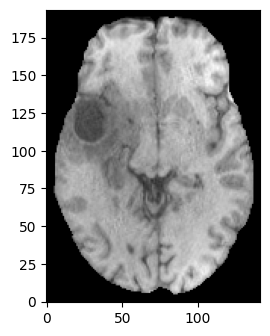

In [7]:
# Title: "Original brain slice"
plot_slices([pad_tumor_slice])

In [8]:
from denoise_rmt import ImgNoiseCorruptor

noise_corruptor = ImgNoiseCorruptor(original_img=pad_tumor_slice)

In [9]:
# Simulation parameters
n_snapshots = 100
random_seed = 1

# Noise parameters
sigma = 35  # Marchenko-Pastur sigma ~ noise standard deviation
rice_b = 2  # Rice distribution parameter

# Generate noisy snapshot and foreground mask
snapshots, fg_masks = noise_corruptor.generate_rician_noisy_displaced_imgs(
    n_snapshots=n_snapshots,
    rice_b=rice_b,
    sigma=sigma,
    seed=random_seed,
)
snapshot = snapshots[0]
fg_mask = fg_masks[0]

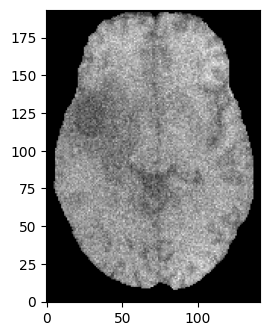

In [10]:
# Title: "Sample of corrupted image"
plot_slices([snapshot])

Denoising 100 snapshots of size 194x142 (sigma = 35, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


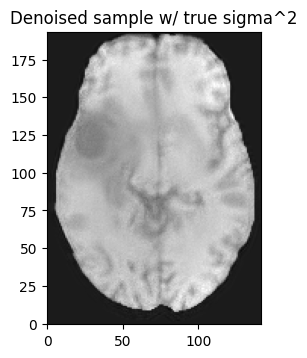

In [11]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma=sigma)

denoised_snapshots_true_sigma = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_true_sigma.shape}")
plot_slices([denoised_snapshots_true_sigma[0]], titles=["Denoised sample w/ true sigma^2"])

Denoising 100 snapshots of size 194x142 (sigma_estimator = 'median' -> sigma_ = 28.8463, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


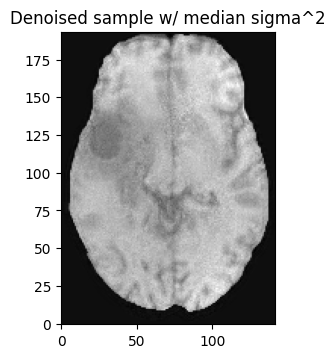

In [12]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma_estimator="median")

denoised_snapshots_median = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_median.shape}")
plot_slices([denoised_snapshots_median[0]], titles=["Denoised sample w/ median sigma^2"])

Denoising 100 snapshots of size 194x142 (sigma_estimator = 'min_eigen' -> sigma_ = 26.8983, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


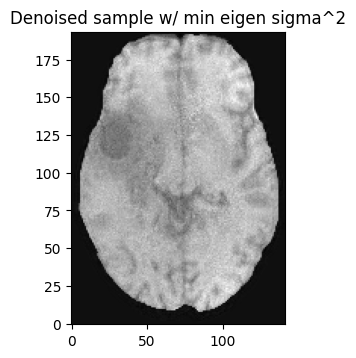

In [13]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma_estimator="min_eigen")

denoised_snapshots_min_eigen = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_min_eigen.shape}")
plot_slices([denoised_snapshots_min_eigen[0]], titles=["Denoised sample w/ min eigen sigma^2"])

Denoising 100 snapshots of size 194x142 (sigma_estimator = 'mp_fit' -> sigma_ = 26.4722, window_size = 16).
Denoised snapshot shape: (100, 194, 142)


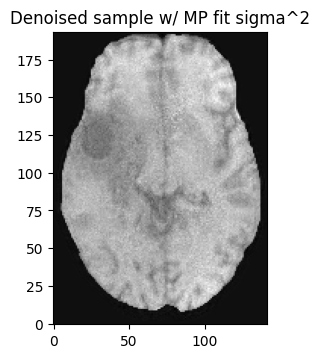

In [14]:
mp_pca_denoiser = MarchenkoPasturPCADenoiser(sigma_estimator="mp_fit")

denoised_snapshots_mp_fit = mp_pca_denoiser.fit_transform(snapshots)
print(f"Denoised snapshot shape: {denoised_snapshots_mp_fit.shape}")
plot_slices([denoised_snapshots_mp_fit[0]], titles=["Denoised sample w/ MP fit sigma^2"])

Denoised by averaging snapshots - shape: (194, 142)


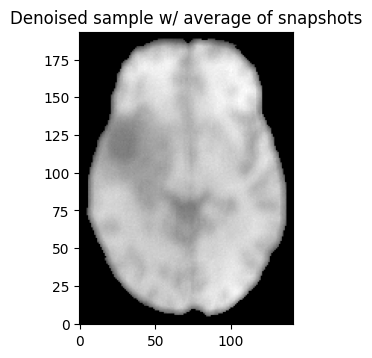

In [26]:
# Image denoised by averaging the noisy snapshots
original_mask = pad_tumor_slice > 0.0
denoised_avg_img = original_mask * np.mean(snapshots, axis=0)

print(f"Denoised by averaging snapshots - shape: {denoised_avg_img.shape}")
plot_slices([denoised_avg_img], titles=["Denoised sample w/ average of snapshots"])

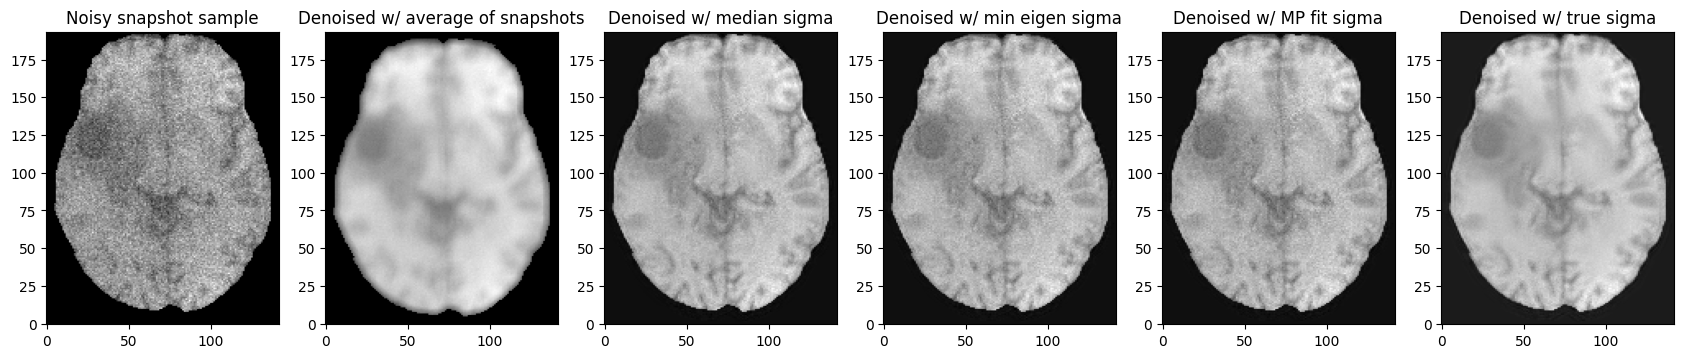

In [29]:
plot_slices(
    [
        snapshots[0],
        denoised_avg_img,
        denoised_snapshots_median[0],
        denoised_snapshots_min_eigen[0],
        denoised_snapshots_mp_fit[0],
        denoised_snapshots_true_sigma[0],
    ],
    titles=[
        "Noisy snapshot sample",
        "Denoised w/ average of snapshots",
        "Denoised w/ median sigma",
        "Denoised w/ min eigen sigma",
        "Denoised w/ MP fit sigma",
        "Denoised w/ true sigma",
    ],
)

### Using metrics from sklearn.denoise.metrics

In [37]:
from skrmt.denoise.metrics import (
    mae,
    rmse,
    snr,
    psnr,
    average_mae,
    average_rmse,
    average_snr,
    average_psnr,
)

In [38]:
print("\nAverage MAE (the lower the better):")
print(f"Noisy snapshots: {average_mae(ref_imgs=pad_tumor_slice, test_imgs=snapshots)}")
print(f"Averaging noisy snapshots: {mae(ref_img=pad_tumor_slice, test_img=denoised_avg_img)}")
print(f"Median sigma: {average_mae(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_median)}")
print(f"Min eigen sigma: {average_mae(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_min_eigen)}")
print(f"MP fit sigma: {average_mae(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_mp_fit)}")
print(f"True sigma: {average_mae(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_true_sigma)}")


Average MAE (the lower the better):
Noisy snapshots: 60.33347134082364
Averaging noisy snapshots: 51.417427685024194


Median sigma: 27.225673737332272
Min eigen sigma: 25.916152629919143
MP fit sigma: 25.68608295325681
True sigma: 30.566342398703615


In [39]:
print("\nAverage RMSE (the lower the better):")
print(f"Noisy snapshots: {average_rmse(ref_imgs=pad_tumor_slice, test_imgs=snapshots)}")
print(f"Averaging noisy snapshots: {rmse(ref_img=pad_tumor_slice, test_img=denoised_avg_img)}")
print(f"Median sigma: {average_rmse(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_median)}")
print(f"Min eigen sigma: {average_rmse(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_min_eigen)}")
print(f"MP fit sigma: {average_rmse(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_mp_fit)}")
print(f"True sigma: {average_rmse(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_true_sigma)}")


Average RMSE (the lower the better):
Noisy snapshots: 80.83873495079884
Averaging noisy snapshots: 64.0193116131421


Median sigma: 37.81489871372983
Min eigen sigma: 36.81804596005948
MP fit sigma: 36.632119109532226
True sigma: 40.23206146969909


In [40]:
print("\nAverage SNR (the higher the better):")
print(f"Noisy snapshots: {average_snr(ref_imgs=pad_tumor_slice, test_imgs=snapshots)}")
print(f"Averaging noisy snapshots: {snr(ref_img=pad_tumor_slice, test_img=denoised_avg_img)}")
print(f"Median sigma: {average_snr(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_median)}")
print(f"Min eigen sigma: {average_snr(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_min_eigen)}")
print(f"MP fit sigma: {average_snr(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_mp_fit)}")
print(f"True sigma: {average_snr(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_true_sigma)}")


Average SNR (the higher the better):
Noisy snapshots: 4.357015139513695
Averaging noisy snapshots: 6.366646869019334
Median sigma: 11.096526916038254
Min eigen sigma: 11.34982406318713
MP fit sigma: 11.398570432626421
True sigma: 10.52943707734743


In [41]:
print("\nAverage PSNR (the higher the better):")
print(f"Noisy snapshots: {average_psnr(ref_imgs=pad_tumor_slice, test_imgs=snapshots)}")
print(f"Averaging noisy snapshots: {psnr(ref_img=pad_tumor_slice, test_img=denoised_avg_img)}")
print(f"Median sigma: {average_psnr(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_median)}")
print(f"Min eigen sigma: {average_psnr(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_min_eigen)}")
print(f"MP fit sigma: {average_psnr(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_mp_fit)}")
print(f"True sigma: {average_psnr(ref_imgs=pad_tumor_slice, test_imgs=denoised_snapshots_true_sigma)}")


Average PSNR (the higher the better):
Noisy snapshots: 9.994951880143695
Averaging noisy snapshots: 12.004583609649336
Median sigma: 16.734463656668257
Min eigen sigma: 16.987760803817135
MP fit sigma: 17.036507173256418
True sigma: 16.167373817977428
